In [1]:
import pandas as pd

In [3]:
df=pd.read_excel(r"C:\Users\Yuvaraj S\OneDrive\Desktop\16MLP\weather_forecast.xlsx")
df

,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [4]:
from sklearn.preprocessing import LabelEncoder

In [5]:
le = LabelEncoder()
df['Outlook'] = le.fit_transform(df['Outlook'])
df

,Outlook,Temperature,Humidity,Windy,Play
0,2,Hot,High,Weak,No
1,2,Hot,High,Strong,No
2,0,Hot,High,Weak,Yes
3,1,Mild,High,Weak,Yes
4,1,Cool,Normal,Weak,Yes
5,1,Cool,Normal,Strong,No
6,0,Cool,Normal,Strong,Yes
7,2,Mild,High,Weak,No
8,2,Cool,Normal,Weak,Yes
9,1,Mild,Normal,Weak,Yes


In [6]:
col = ['Temperature','Humidity','Windy','Play']
for i in col:
    df[i] = le.fit_transform(df[i])
df

,Outlook,Temperature,Humidity,Windy,Play
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1
5,1,0,1,0,0
6,0,0,1,0,1
7,2,2,0,1,0
8,2,0,1,1,1
9,1,2,1,1,1


In [7]:
d1=pd.read_excel(r"C:\Users\Yuvaraj S\OneDrive\Desktop\16MLP\weather_forecast.xlsx")
d1

,Outlook,Temperature,Humidity,Windy,Play
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


In [8]:
l1 = d1.columns
l1

Index(['Outlook', 'Temperature', 'Humidity', 'Windy', 'Play'], dtype='object')

In [9]:
encoded_df=pd.get_dummies(d1,dtype=int)
encoded_df

,Outlook_Overcast,Outlook_Rain,Outlook_Sunny,Temperature_Cool,Temperature_Hot,Temperature_Mild,Humidity_High,Humidity_Normal,Windy_Strong,Windy_Weak,Play_No,Play_Yes
0,0,0,1,0,1,0,1,0,0,1,1,0
1,0,0,1,0,1,0,1,0,1,0,1,0
2,1,0,0,0,1,0,1,0,0,1,0,1
3,0,1,0,0,0,1,1,0,0,1,0,1
4,0,1,0,1,0,0,0,1,0,1,0,1
5,0,1,0,1,0,0,0,1,1,0,1,0
6,1,0,0,1,0,0,0,1,1,0,0,1
7,0,0,1,0,0,1,1,0,0,1,1,0
8,0,0,1,1,0,0,0,1,0,1,0,1
9,0,1,0,0,0,1,0,1,0,1,0,1


In [10]:
from sklearn.model_selection import train_test_split

In [11]:
x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,:-1],df.iloc[:,-1],test_size=0.3,shuffle=True,random_state=12)

In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)
#train prediction
y_train_pred = dt.predict(x_train)
#test prediction
y_test_pred = dt.predict(x_test) 

In [14]:
df['Play'].value_counts()

Play
1    9
0    5
Name: count, dtype: int64

In [15]:
from sklearn.metrics import confusion_matrix,classification_report

In [16]:
confusion_matrix(y_train,y_train_pred)

array([[3, 0],
       [0, 6]])

In [17]:
print(classification_report(y_train,y_train_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         6

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9



In [18]:
confusion_matrix(y_test,y_test_pred)

array([[0, 2],
       [1, 2]])

In [19]:
print(classification_report(y_test,y_test_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      0.67      0.57         3

    accuracy                           0.40         5
   macro avg       0.25      0.33      0.29         5
weighted avg       0.30      0.40      0.34         5



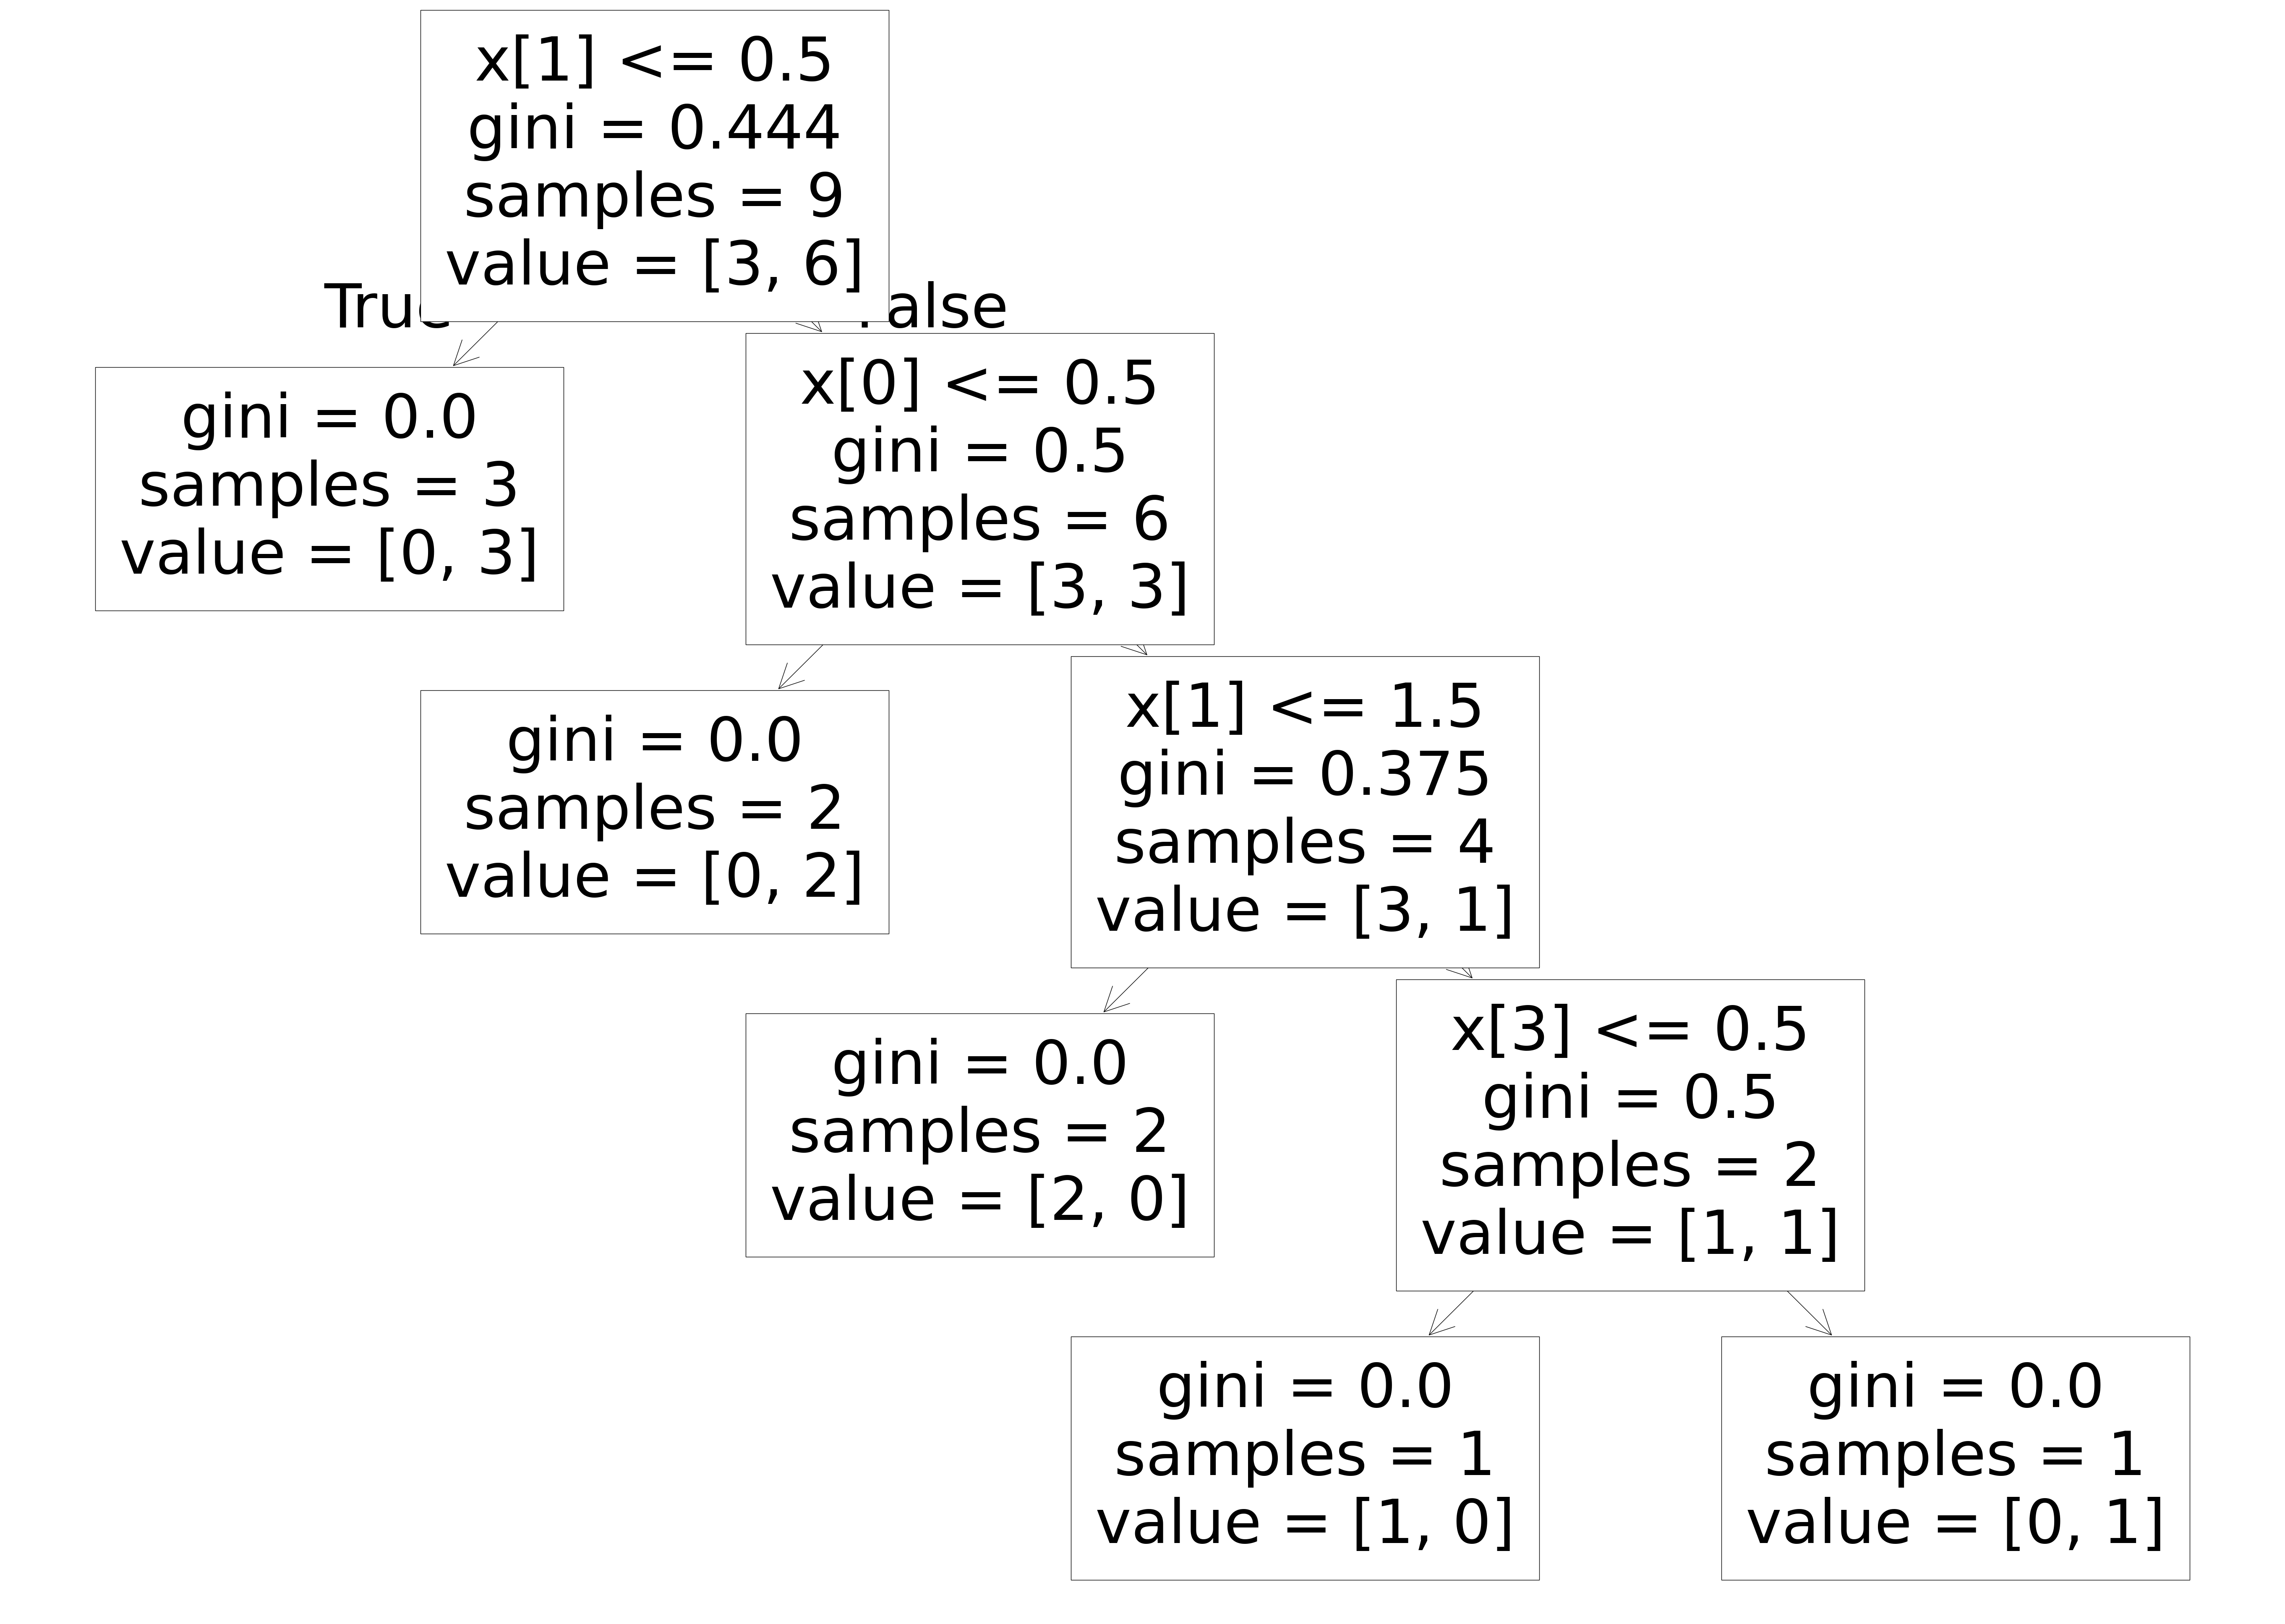

In [21]:
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(70,50))
plot_tree(decision_tree = dt,proportion=False)

plt.show()